In [1]:
import numpy as np
import pandas as pd
import tkinter as tk
from tkinter import filedialog
from pyFAI.test.utilstest import UtilsTest
from pyFAI.gui.jupyter import subplots, display, plot1d, plot2d
from pyFAI import load
import pyFAI
# from pyFAI.azimuthalIntegrator import AzimuthalIntegrator
from pyFAI.integrator.fiber import FiberIntegrator
from pyFAI.integrator import azimuthal
from pyFAI.units import get_unit_fiber
from pyFAI.integrator.azimuthal import AzimuthalIntegrator
from pyFAI.io.ponifile import PoniFile
import fabio
import time
import matplotlib.pyplot as plt


In [2]:
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
root.update()
image_file = filedialog.askopenfilename(
    title="Select GIWAXS Image File",
    filetypes=[("Image files", "*.tif;*.tiff"), ("All files", "*.*")]
)
poni_file = filedialog.askopenfilename(
    title="Select Calibration File",
    filetypes=[("PONI files", "*.poni"), ("All files", "*.*")]
)
image_savefile = filedialog.asksaveasfilename(
    title="Save Plot As",
    filetypes=[("PNG files", "*.png"), ("PDF files", "*.pdf"), ("All files", "*.*")]
)
dataframe_file = image_savefile.replace(".png", ".csv")

wavelength = 1.2398419843320025  # 10 keV in Å

Detector Pilatus 1M	 PixelSize= 172µm, 172µm	 BottomRight (3)
Wavelength= 1.239842e-10 m
SampleDetDist= 1.931528e-01 m	PONI= 8.826654e-02, 4.016368e-02 m	rot1=-0.679401  rot2=0.012051  rot3=0.000000 rad
DirectBeamDist= 248.302 mm	Center: x=1140.509, y=530.574 pix	Tilt= 38.932° tiltPlanRotation= 1.099° 𝛌= 1.240Å


<Axes: title={'center': '2D regrouping'}, xlabel='Scattering vector $q$ ($nm^{-1}$)', ylabel='Azimuthal angle $\\chi$ ($^{o}$)'>

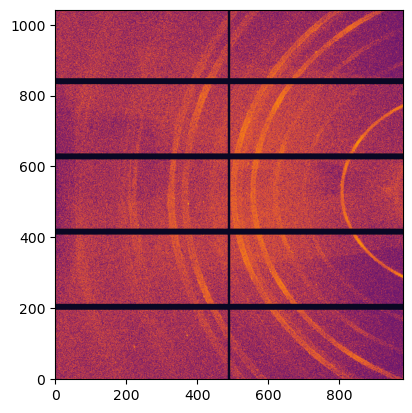

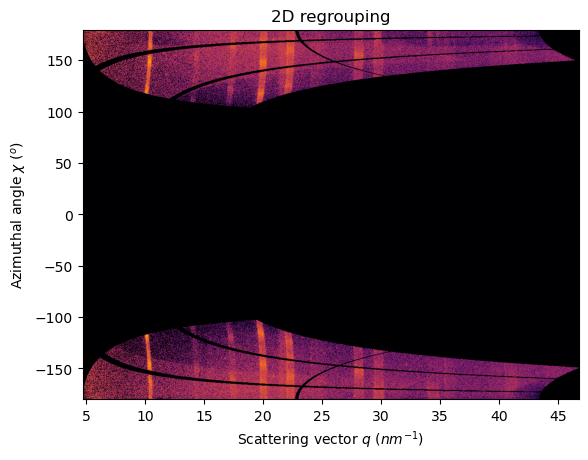

In [3]:
image = fabio.open(image_file).data

# Load the calibration file
# fi = ai.promote(type_="pyFAI.integrator.fiber.FiberIntegrator")
ai = AzimuthalIntegrator()
ai.load(poni_file)
print(ai)
# image = np.clip(image, 0, None)  # Clip the image to avoid negative values
alpha_i = 2*(2*np.pi)/360 # 2 degrees in radians
unit_qip = get_unit_fiber(name="qip_nm^-1", incident_angle=alpha_i, tilt_angle=0, sample_orientation=8) # q_r unit definition
unit_qoop = get_unit_fiber(name="qoop_nm^-1", incident_angle=alpha_i, tilt_angle=0, sample_orientation=8) # q_z

res2d = ai.integrate2d(image, 1024, 1024, method=("no", "csr", "cython")) #convert to q_r and q_z

display(image)
plot2d(res2d)


poni.poni1 0.08826653831105538
poni.poni2 0.04016368385785257


<Axes: title={'center': '2D regrouping'}, xlabel='Scattering vector $q$ ($\\AA^{-1}$)', ylabel='Azimuthal angle $\\chi$ ($^{o}$)'>

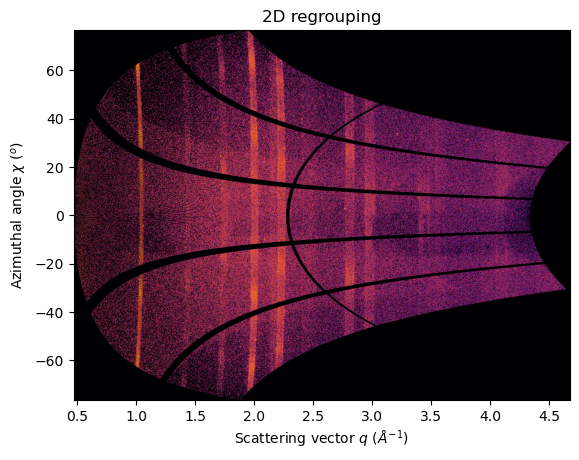

In [ ]:
poni = PoniFile(data=poni_file)
pixel_to_um = 172.0
full_length = 981*pixel_to_um/1000000
print("poni.poni1", poni.poni1)
print("poni.poni2", poni.poni2)

ai2 = AzimuthalIntegrator(dist=poni.dist, poni1=poni.poni1, poni2=full_length -poni.poni2,
                     wavelength=poni.wavelength,
                     rot1=np.pi - poni.rot1, rot2=np.pi - poni.rot2, rot3=poni.rot3,
                     detector=pyFAI.detector_factory("Pilatus1M", {"orientation": 4}),
                    )
res2d2 = ai2.integrate2d(image, 1024, 1024, method=("no", "csr", "cython"), unit = "q_A^-1")
plot2d(res2d2)

c:\Users\raglo\anaconda3\envs\giwaxs_analysis_new3\Lib\site-packages\pyFAI\integrator\azimuthal.py:615: RuntimeWarning: invalid value encountered in divide
  intensity = sum_signal / sum_normalization


<Axes: title={'center': '1D integration'}, xlabel='Azimuthal angle $\\chi$ ($^{o}$)', ylabel='Intensity'>

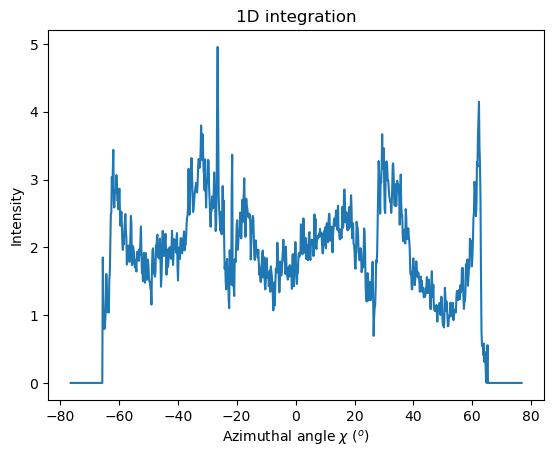

In [6]:
res1d = ai2.integrate_radial(image, 900, radial_range=(.9, 1.1), radial_unit="q_A^-1")
plot1d(res1d)

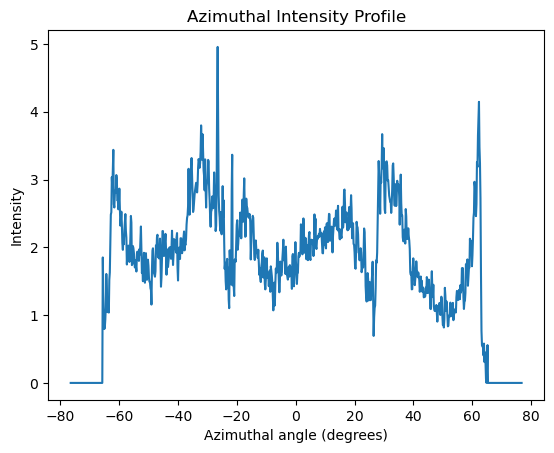

Hermans orientation factor: -0.09314639181030265


In [7]:
I = res1d.intensity
chi = res1d.radial
#herman's orientation factor
plt.plot(chi, I)
plt.xlabel("Azimuthal angle (degrees)")
plt.ylabel("Intensity")
plt.title("Azimuthal Intensity Profile")
plt.show()
def hermans_orientation_factor(I, chi):
    """
    Calculate Hermans orientation factor from intensity and azimuthal angle.
    """
    #integrate the intensity over azimuthal angle
    numerator = np.trapezoid(I * np.cos(chi)**2 * np.sin(chi), chi)
    denominator = np.trapezoid(I * np.sin(chi), chi)
    #calculate the Hermans orientation factor
    cos_term = numerator / denominator
    H = (3 * cos_term - 1) / 2
    
    return H

print("Hermans orientation factor:", hermans_orientation_factor(I, chi))

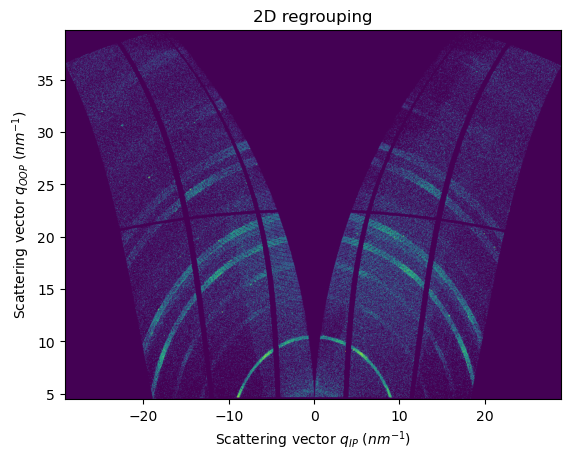

In [ ]:
# fi = load(filename=poni_file, type_="pyFAI.integrator.fiber.FiberIntegrator")
# fi = ai.promote(type_="pyFAI.integrator.fiber.FiberIntegrator")
fi = FiberIntegrator(
    dist=poni.dist,
    poni1=poni.poni1,
    poni2=full_length - poni.poni2,
    wavelength=poni.wavelength,
    rot1=np.pi - poni.rot1,
    rot2=np.pi - poni.rot2,
    rot3=poni.rot3,
    detector=pyFAI.detector_factory("Pilatus1M", {"orientation": 4}),
)
# fi = load(filename=poni_file, type_="pyFAI.integrator.fiber.FiberIntegrator")

# print(fi)
# fi.reset_integrator(incident_angle=alpha_i, tilt_angle=0,  sample_orientation=4)
# print(fi)
# print(fi)
# res = fi.integrate2d_grazing_incidence(image, npt_oop=1024, npt_ip=1024, oop_range=[0,20], ip_range=[0,20], incident_angle=alpha_i, tilt_angle=0, sample_orientation=1) #convert to q_r and q_z
res = fi.integrate2d_grazing_incidence(
    data=image, incident_angle=alpha_i, tilt_angle=0, sample_orientation=6
)


def update_style(ax):
    for img in ax.get_images():
        img.set_cmap("viridis")
        img.set_clim(1, 30)


fig, ax = subplots()
plot2d(result=res, ax=ax)
update_style(ax=ax)
# print(res)